 Surrogate Tree Rules
|--- remainder__age <= 29.50
|   |--- remainder__density <= 190.01
|   |   |--- cat__job_Unemployed <= 0.50
|   |   |   |--- value: [544.90]
|   |   |--- cat__job_Unemployed >  0.50
|   |   |   |--- value: [836.55]
|   |--- remainder__density >  190.01
|   |   |--- remainder__age <= 22.50
|   |   |   |--- value: [1203.16]
|   |   |--- remainder__age >  22.50
|   |   |   |--- value: [875.69]
|--- remainder__age >  29.50
|   |--- remainder__density <= 151.84
|   |   |--- remainder__density <= 88.06
|   |   |   |--- value: [225.10]
|   |   |--- remainder__density >  88.06
|   |   |   |--- value: [293.90]
|   |--- remainder__density >  151.84
|   |   |--- remainder__density <= 237.55
|   |   |   |--- value: [379.12]
|   |   |--- remainder__density >  237.55
|   |   |   |--- value: [494.52]


Leaf Summary Table 
              customer_count  mean_expected_loss
segment_leaf                                    
1203.158475              910         1203.158475
875.688174  

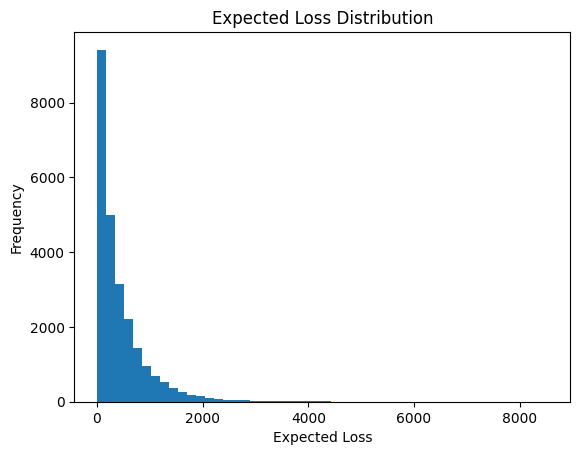

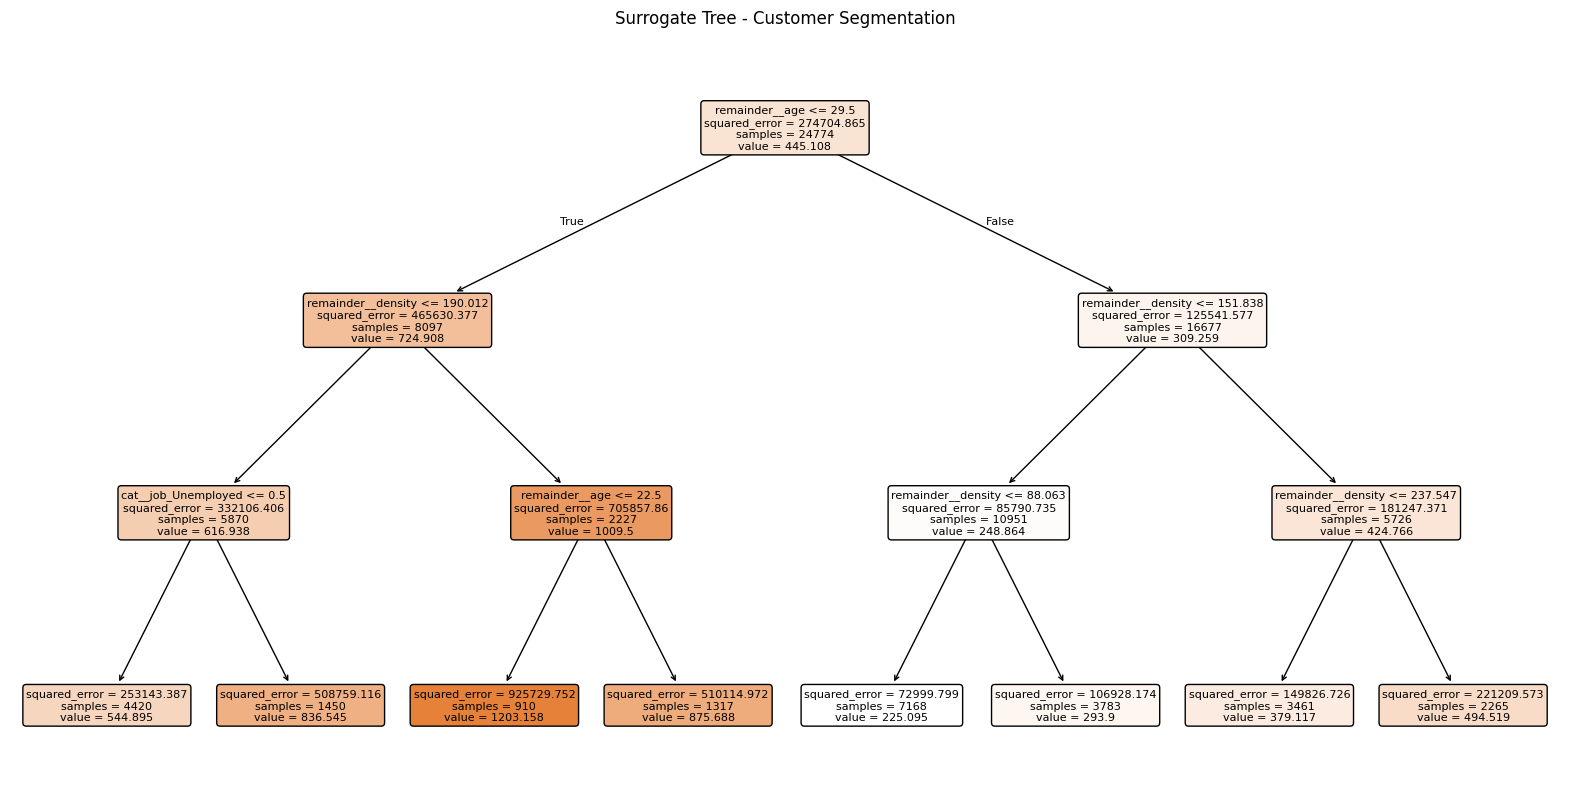

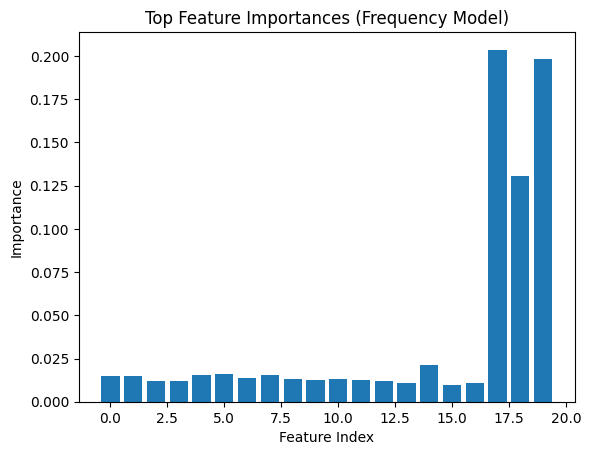

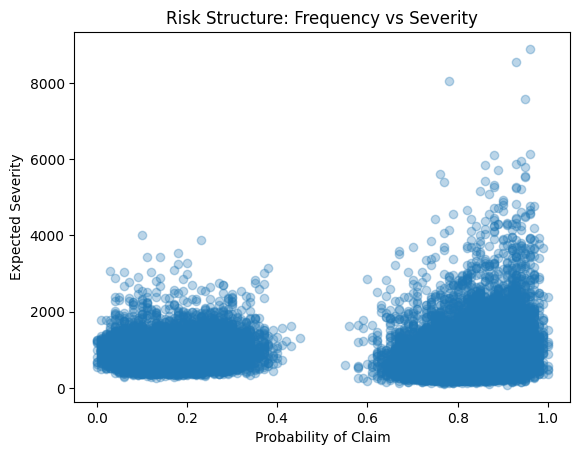

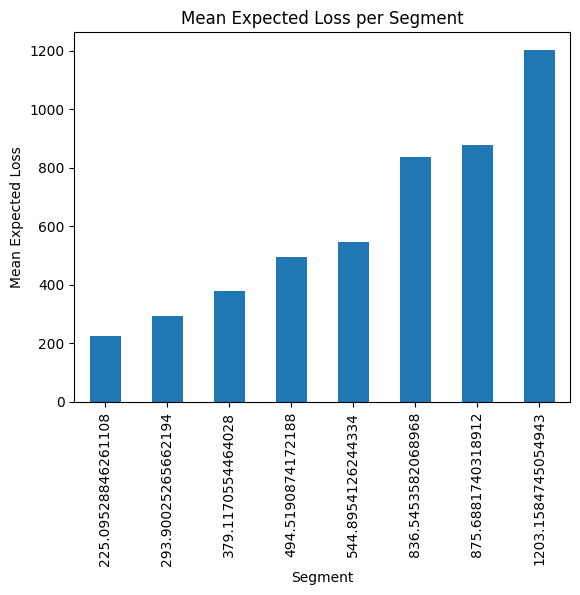

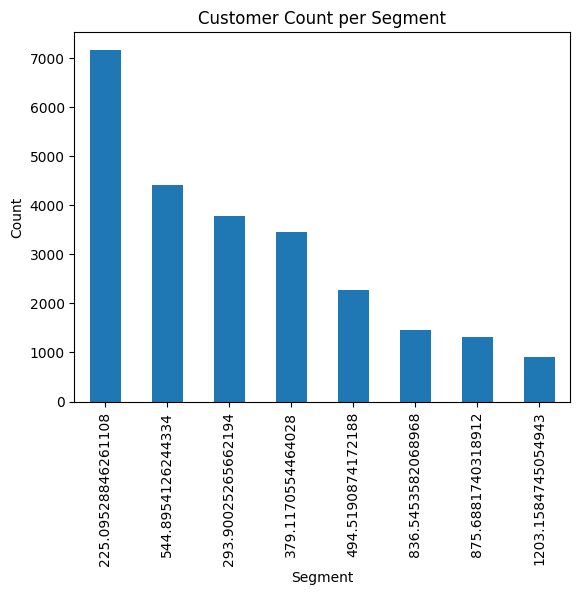

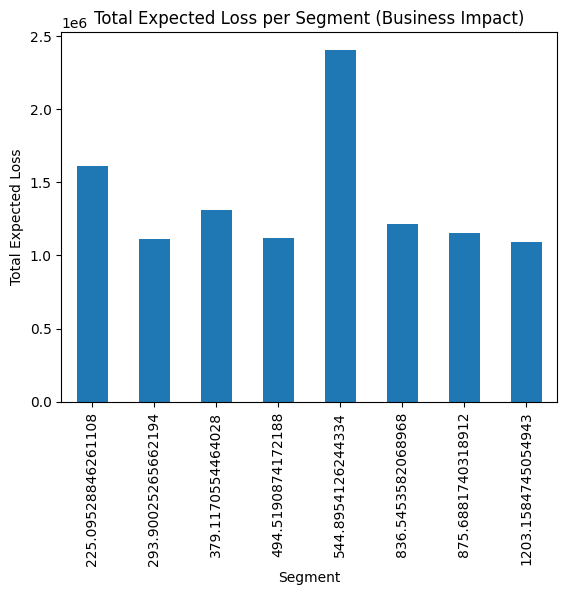

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor, export_text
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


# 1. DATA LOADING and PREPARATION
freq_df = pd.read_csv('frequency.csv')
sev_df = pd.read_csv('severity.csv')

# Define features and targets
categorical_cols = ['uwYear', 'gender', 'carType', 'carCat', 'job']
numeric_cols = ['age', 'nYears', 'carVal', 'cover', 'density']
features = categorical_cols + numeric_cols

X_freq = freq_df[features]
y_freq = freq_df['claimNumbMD'] # Binary target (1=claim, 0=no claim)
X_sev = sev_df[features]
y_sev = sev_df['claimSizeMD']   # Continuous target (cost in euro)

# Create a preprocessing pipeline to handle categorical variables
# Tree-based models can handle raw data, but one-hot encoding ensures smooth 
# integration across standard scikit-learn algorithms.
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ], remainder='passthrough'
)

# 2. SEPARATE MODELS For FREQUENCY AND SEVERITY
# Fit one model on the frequency data to estimate the probability of a claim,
# and another model on the severity data to estimate expected claim size.
# We use Random Forests here as our model to capture complex interactions.

freq_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

sev_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Train models on their respective unlinked datasets
freq_model.fit(X_freq, y_freq)
sev_model.fit(X_sev, y_sev)


# 3. SCORE FUSION (Unified risk score)
# Apply both models to a common covariate dataset and combine the 
# predictions into an expected-loss score.
# We use the larger frequency dataset as our common "portfolio" profile base.

# Predict probability of a claim
prob_claim = freq_model.predict_proba(X_freq)[:, 1]

# Predict expected severity (cost) if a claim occurs
expected_severity = sev_model.predict(X_freq)

# Calculate expected loss. Because premium isn't provided, this treats expected 
# claims cost as a proxy for profitability risk.
freq_df['expected_loss'] = prob_claim * expected_severity


# 4. SURROGATE TREE (simplification)
# Use that model's predicted expected-loss values as the target for a 
# small surrogate tree. The rich model captures complexity, the small tree 
# provides a simplified explanation.
# We limit depth to prevent the problem of too many paths.
surrogate_tree = Pipeline([
    ('preprocessor', preprocessor),
    ('tree', DecisionTreeRegressor(max_depth=3, random_state=42)) 
])

# Fit the shallow tree strictly on the expected_loss predictions, not the raw data.
surrogate_tree.fit(X_freq, freq_df['expected_loss'])


# 5. LEAF RANKING
# Raw trees can become too detailed for clients.
# We output the rules so they can be summarized into a segment table.

# Extract feature names after one-hot encoding for readability
feature_names = surrogate_tree.named_steps['preprocessor'].get_feature_names_out()
tree_model = surrogate_tree.named_steps['tree']

print(" Surrogate Tree Rules")
# This prints the structural rules to identify dominant characteristics of each leaf.
tree_rules = export_text(tree_model, feature_names=list(feature_names))
print(tree_rules)

# Add the surrogate tree's segment assignment back to the dataset to calculate leaf summaries
freq_df['segment_leaf'] = surrogate_tree.predict(X_freq)

print("\nLeaf Summary Table ")
# For each leaf, we would summarize segment size and expected loss
leaf_summary = freq_df.groupby('segment_leaf').agg(
    customer_count=('expected_loss', 'size'),
    mean_expected_loss=('expected_loss', 'mean')
).sort_values(by='mean_expected_loss', ascending=False)
print(leaf_summary)




# simple visuals
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# 1. EXPECTED LOSS DISTRIBUTION
plt.figure()
plt.hist(freq_df['expected_loss'], bins=50)
plt.title("Expected Loss Distribution")
plt.xlabel("Expected Loss")
plt.ylabel("Frequency")
plt.savefig("expected_loss_dist.png")


# 2. TREE VISUALIZATION
plt.figure(figsize=(20, 10))
plot_tree(
    tree_model,
    feature_names=feature_names,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Surrogate Tree - Customer Segmentation")
plt.savefig("surrogate_tree.png")


# 3. FEATURE IMPORTANCE
rf = freq_model.named_steps['classifier']
importances = rf.feature_importances_
plt.figure()
plt.bar(range(len(importances[:20])), importances[:20])
plt.title("Top Feature Importances (Frequency Model)")
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.savefig("feature_importance.png")


# 4. RISK STRUCTURE
plt.figure()
plt.scatter(prob_claim, expected_severity, alpha=0.3)
plt.xlabel("Probability of Claim")
plt.ylabel("Expected Severity")
plt.title("Risk Structure: Frequency vs Severity")
plt.savefig("risk_scatter.png")


# 5. SEGMENT (LEAF) DISTRIBUTION
plt.figure()
freq_df.groupby('segment_leaf')['expected_loss'].mean().plot(kind='bar')
plt.title("Mean Expected Loss per Segment")
plt.xlabel("Segment")
plt.ylabel("Mean Expected Loss")
plt.savefig("segment_loss.png")


# 6. SEGMENT SIZE 
plt.figure()
freq_df['segment_leaf'].value_counts().plot(kind='bar')
plt.title("Customer Count per Segment")
plt.xlabel("Segment")
plt.ylabel("Count")
plt.savefig("segment_size.png")


# 7. SEGMENT VALUE 
segment_total = freq_df.groupby('segment_leaf')['expected_loss'].sum()
plt.figure()
segment_total.plot(kind='bar')
plt.title("Total Expected Loss per Segment (Business Impact)")
plt.xlabel("Segment")
plt.ylabel("Total Expected Loss")
plt.savefig("segment_total_loss.png")